In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)
import os
import shutil
import random

# 设置随机种子，保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# 数据集原始路径
base_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/'
train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')

# 查看一下原始 train 里的类别数量（这正好是报告里要的统计）
for cls in ['NORMAL', 'PNEUMONIA']:
    path = os.path.join(train_dir, cls)
    num = len(os.listdir(path))
    print(f"原始 train/{cls}: {num} 张")

2026-04-27 12:12:51.439922: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777291971.636994      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777291971.696629      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777291972.139215      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777291972.139250      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777291972.139253      55 computation_placer.cc:177] computation placer alr

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/chest-xray-pneumonia/chest_xray/train/NORMAL'

In [4]:
import os
# 列出 input 目录下所有文件夹和文件
for item in os.listdir('/kaggle/input/'):
    print(item)

datasets
notebooks


In [5]:
import os
# 列出 input 目录下所有文件夹和文件
for item in os.listdir('/kaggle/input/'):
    print(item)

datasets
notebooks


In [6]:
!pip install kagglehub -q

In [7]:
import kagglehub
import shutil, os

# 下载数据集（kagglehub 会自动处理）
print("开始下载，请等待...")
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("下载完成！缓存路径：", path)

# 复制到 /kaggle/working/chest_xray/ 下面，方便我们使用
dst = "/kaggle/working/chest_xray/"
if not os.path.exists(dst):
    shutil.copytree(os.path.join(path, "chest_xray"), dst)
    print("数据已复制到", dst)
else:
    print("目标文件夹已存在，跳过复制。")

开始下载，请等待...
下载完成！缓存路径： /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia
数据已复制到 /kaggle/working/chest_xray/


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)
import os
import shutil
import random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# 数据已下载至 /kaggle/working/chest_xray/
base_path = '/kaggle/working/chest_xray/'
train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')

In [11]:
new_base = '/kaggle/working/split_data/'
for subset in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        os.makedirs(os.path.join(new_base, subset, cls), exist_ok=True)

# 复制 test（原 test 保持不变）
for cls in ['NORMAL', 'PNEUMONIA']:
    src = os.path.join(test_dir, cls)
    dst = os.path.join(new_base, 'test', cls)
    for f in os.listdir(src):
        shutil.copy(os.path.join(src, f), os.path.join(dst, f))

# 收集 train 所有文件
train_files = []
for cls in ['NORMAL', 'PNEUMONIA']:
    src_dir = os.path.join(train_dir, cls)
    for f in os.listdir(src_dir):
        train_files.append((os.path.join(src_dir, f), cls))

# 8:2 分层划分
train_list, val_list = train_test_split(
    train_files, test_size=0.2,
    stratify=[x[1] for x in train_files], random_state=42
)

# 复制到新位置
for fpath, cls in train_list:
    shutil.copy(fpath, os.path.join(new_base, 'train', cls, os.path.basename(fpath)))
for fpath, cls in val_list:
    shutil.copy(fpath, os.path.join(new_base, 'val', cls, os.path.basename(fpath)))

# 打印数据分布（报告要用）
print("========== 重新划分后的数据统计 ==========")
for subset in ['train', 'val', 'test']:
    norm = len(os.listdir(os.path.join(new_base, subset, 'NORMAL')))
    pneu = len(os.listdir(os.path.join(new_base, subset, 'PNEUMONIA')))
    print(f"{subset}: NORMAL = {norm}, PNEUMONIA = {pneu}, 总计 = {norm+pneu}")

========== 重新划分后的数据统计 ==========
train: NORMAL = 1073, PNEUMONIA = 3099, 总计 = 4172
val: NORMAL = 268, PNEUMONIA = 776, 总计 = 1044
test: NORMAL = 234, PNEUMONIA = 390, 总计 = 624


In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(new_base, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(new_base, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(new_base, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("类别映射：", train_generator.class_indices)

Found 4172 images belonging to 2 classes.
Found 1044 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
类别映射： {'NORMAL': 0, 'PNEUMONIA': 1}


In [13]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777293260.864716      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[callback]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1777293273.367210     150 service.cc:152] XLA service 0x7e1e5c005990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777293273.367259     150 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777293273.780078     150 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/131 ━━━━━━━━━━━━━━━━━━━━ 14:38 7s/step - accuracy: 0.6250 - loss: 0.6893

I0000 00:00:1777293278.038536     150 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


131/131 ━━━━━━━━━━━━━━━━━━━━ 87s 616ms/step - accuracy: 0.7480 - loss: 0.5432 - val_accuracy: 0.7893 - val_loss: 0.3912
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 76s 577ms/step - accuracy: 0.8644 - loss: 0.3131 - val_accuracy: 0.9080 - val_loss: 0.2227
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 76s 578ms/step - accuracy: 0.8869 - loss: 0.2597 - val_accuracy: 0.9119 - val_loss: 0.2090
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 75s 570ms/step - accuracy: 0.8998 - loss: 0.2565 - val_accuracy: 0.9061 - val_loss: 0.2110
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 75s 575ms/step - accuracy: 0.9075 - loss: 0.2361 - val_accuracy: 0.9310 - val_loss: 0.1726
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 77s 587ms/step - accuracy: 0.9042 - loss: 0.2438 - val_accuracy: 0.9444 - val_loss: 0.1576
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 75s 574ms/step - accuracy: 0.9112 - loss: 0.2122 - val_accuracy: 0.9310 - val_loss: 0.1644
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 74s 568ms/step - accuracy: 0.9217 - loss: 0.2125 - val

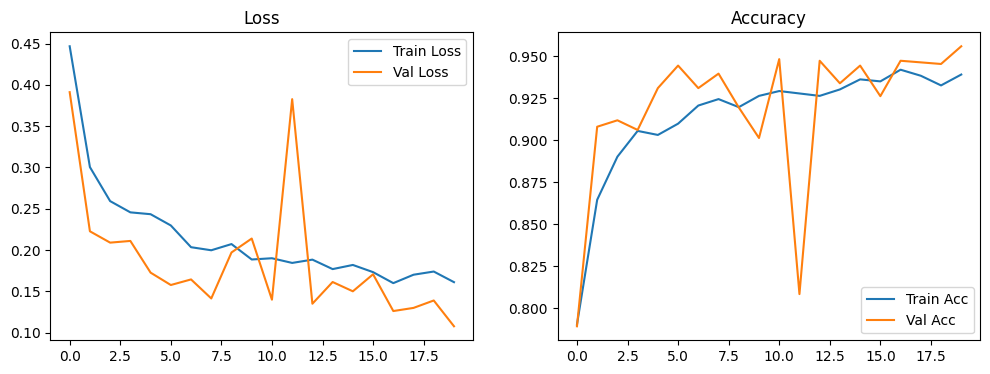

In [15]:
os.makedirs('figures', exist_ok=True)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.savefig('figures/training_curves.png')
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step
Accuracy:  0.8397
Precision: 0.8033
Recall:    0.9846
F1 Score:  0.8848


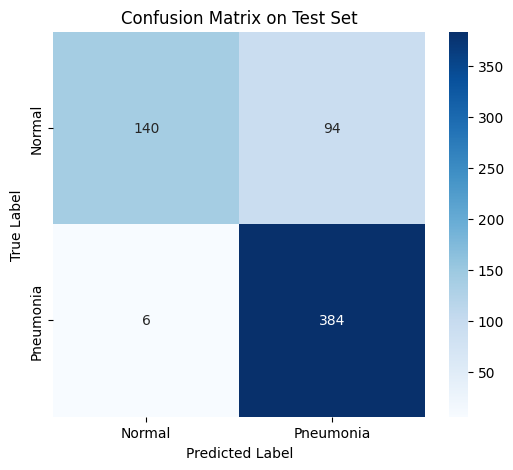

In [16]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 获取真实标签
y_true = test_generator.classes

# 2. 获取预测概率并转换为 0/1 预测
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# 3. 计算四项指标
acc = accuracy_score(y_true, y_pred)
pre = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 4. 生成混淆矩阵并保存
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.savefig('figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()